# Final Model Analysis Dashboard

This notebook is the **single presentation and paper dashboard** for the EEG dynamic regime modeling project.

It is designed to:

- load all saved model outputs from `outputs/`,
- build a final comparison table,
- produce all core figures,
- summarize the scientific interpretation.

Models covered:

- pooled factor-PVAR
- baselines
- switching PVAR prototype
- Option A: switching factor-PVAR
- Option B: unit-specific switching PVAR
- Option C: SLDS-style panel prototype


In [1]:
import sys
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import config

warnings.filterwarnings('ignore')

try:
    import networkx as nx
    HAS_NX = True
except Exception:
    HAS_NX = False

plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
OUTPUT_DIR = Path(PROJECT_ROOT/config.OUTPUT_DIR)
print('Using outputs directory:', OUTPUT_DIR.resolve())


Using outputs directory: D:\Programming\EEG-Research\outputs


## Helpers

In [29]:
def project_rows_to_simplex(Y, eps=1e-8):
    Y = np.asarray(Y, dtype=float)
    Y = np.clip(Y, eps, None)
    Y /= np.sum(Y, axis=1, keepdims=True)
    return Y

def load_npz_if_exists(path):
    path = Path(path)
    if not path.exists():
        print(f'[missing] {path.name}')
        return None
    print(f'[loaded]  {path.name}')
    return np.load(path, allow_pickle=True)

def load_csv_if_exists(path):
    path = Path(path)
    if not path.exists():
        print(f'[missing] {path.name}')
        return None
    print(f'[loaded]  {path.name}')
    return pd.read_csv(path)

def row_normalize(df):
    return df.div(df.sum(axis=1).replace(0, np.nan), axis=0)

def summarize_A(A):
    rows = []
    K = A.shape[0]
    for k in range(K):
        Ak = A[k]
        diag_mean = np.mean(np.diag(Ak))
        offdiag = Ak - np.diag(np.diag(Ak))
        offdiag_mean = np.mean(np.abs(offdiag))
        rows.append({
            'regime': f'Regime {k+1}',
            'mean_diag_A': diag_mean,
            'mean_abs_offdiag_A': offdiag_mean,
        })
    return pd.DataFrame(rows)

def summarize_B(B):
    rows = []
    K = B.shape[0]
    for k in range(K):
        rows.append({
            'regime': f'Regime {k+1}',
            'mean_abs_covariate_effect': np.mean(np.abs(B[k]))
        })
    return pd.DataFrame(rows)

def top_covariates(B, feature_names, top_n=15):
    out = {}
    K = B.shape[0]
    for k in range(K):
        imp = np.mean(np.abs(B[k]), axis=1)
        df = pd.DataFrame({'covariate': feature_names, 'importance': imp}).sort_values('importance', ascending=False).head(top_n)
        out[f'Regime {k+1}'] = df
    return out

def plot_transition_matrix(Pi, title='Transition matrix',file_name=None):
    fig, ax = plt.subplots(figsize=(5,4))
    im = ax.imshow(Pi, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('To regime')
    ax.set_ylabel('From regime')
    ax.set_xticks(range(Pi.shape[1]))
    ax.set_yticks(range(Pi.shape[0]))
    ax.set_xticklabels([f'{i+1}' for i in range(Pi.shape[1])])
    ax.set_yticklabels([f'{i+1}' for i in range(Pi.shape[0])])
    for i in range(Pi.shape[0]):
        for j in range(Pi.shape[1]):
            ax.text(j, i, f'{Pi[i,j]:.3f}', ha='center', va='center', color='white')
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()

def plot_A_heatmaps(A, title_prefix='AR matrix',file_name=None):
    K = A.shape[0]
    fig, axes = plt.subplots(1, K, figsize=(5*K, 4), constrained_layout=True)
    if K == 1:
        axes = [axes]
    for k in range(K):
        im = axes[k].imshow(A[k], aspect='auto')
        axes[k].set_title(f'{title_prefix} Regime {k+1}')
        axes[k].set_xlabel('Response state')
        axes[k].set_ylabel('Lagged state')
    fig.colorbar(im, ax=axes, shrink=0.8)
    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()

def confusion_from_probs(y_true, y_pred):
    true_state = np.argmax(y_true, axis=1)
    pred_state = np.argmax(y_pred, axis=1)
    conf = pd.crosstab(pd.Series(true_state, name='true'), pd.Series(pred_state, name='pred'))
    conf_row = row_normalize(conf)
    return conf, conf_row

def plot_confusion_heatmap(conf_row, title='Row-normalized confusion matrix',file_name=None):
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(conf_row.values, aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Predicted dominant state')
    ax.set_ylabel('True dominant state')
    ax.set_xticks(range(conf_row.shape[1]))
    ax.set_yticks(range(conf_row.shape[0]))
    ax.set_xticklabels(conf_row.columns)
    ax.set_yticklabels(conf_row.index)
    for i in range(conf_row.shape[0]):
        for j in range(conf_row.shape[1]):
            ax.text(j, i, f'{conf_row.values[i,j]:.2f}', ha='center', va='center', color='white')
    fig.colorbar(im, ax=ax, shrink=0.8)
    plt.tight_layout()
    if file_name:
        plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.show()

def plot_state_interaction_network(Ak, threshold=0.02, title='State interaction network'):
    if not HAS_NX:
        print('networkx is not installed; skipping network plot.')
        return
    G = nx.DiGraph()
    state_names = [f'State {i}' for i in range(Ak.shape[0])]
    for s in state_names:
        G.add_node(s)
    for i in range(Ak.shape[0]):
        for j in range(Ak.shape[1]):
            w = float(Ak[i, j])
            if abs(w) >= threshold:
                G.add_edge(state_names[i], state_names[j], weight=w)
    pos = nx.circular_layout(G)
    weights = [abs(G[u][v]['weight']) * 10 for u, v in G.edges()]
    plt.figure(figsize=(5,5))
    nx.draw(G, pos, with_labels=True, node_color='lightblue', width=weights, arrows=True)
    plt.title(title)
    plt.show()


## Load available metrics and artifacts

In [3]:
files = {
    'pvar_metrics': OUTPUT_DIR / 'vmf_pvar_pooled_metrics.csv',
    'pvar_artifacts': OUTPUT_DIR / 'vmf_pvar_pooled_artifacts.npz',
    'baseline_metrics': OUTPUT_DIR / 'vmf_baseline_comparison.csv',
    'switch_metrics': OUTPUT_DIR / 'switching_pvar_k3_metrics.csv',
    'switch_artifacts': OUTPUT_DIR / 'switching_pvar_k3_artifacts.npz',
    'optA_metrics': OUTPUT_DIR / 'switching_factor_pvar_k3_metrics.csv',
    'optA_artifacts': OUTPUT_DIR / 'switching_factor_pvar_k3_artifacts.npz',
    'optB_metrics': OUTPUT_DIR / 'unit_switching_pvar_k3_metrics.csv',
    'optB_artifacts': OUTPUT_DIR / 'unit_switching_pvar_k3_artifacts.npz',
    'optC_metrics': OUTPUT_DIR / 'slds_panel_k3_r3_metrics.csv',
    'optC_artifacts': OUTPUT_DIR / 'slds_panel_k3_r3_artifacts.npz',
}

loaded = {k: (load_csv_if_exists(v) if v.suffix == '.csv' else load_npz_if_exists(v)) for k, v in files.items()}


[loaded]  vmf_pvar_pooled_metrics.csv
[loaded]  vmf_pvar_pooled_artifacts.npz
[loaded]  vmf_baseline_comparison.csv
[loaded]  switching_pvar_k3_metrics.csv
[loaded]  switching_pvar_k3_artifacts.npz
[loaded]  switching_factor_pvar_k3_metrics.csv
[loaded]  switching_factor_pvar_k3_artifacts.npz
[loaded]  unit_switching_pvar_k3_metrics.csv
[loaded]  unit_switching_pvar_k3_artifacts.npz
[loaded]  slds_panel_k3_r3_metrics.csv
[loaded]  slds_panel_k3_r3_artifacts.npz


## Final comparison table

In [4]:
frames = []
for key in ['pvar_metrics', 'baseline_metrics', 'switch_metrics', 'optA_metrics', 'optB_metrics', 'optC_metrics']:
    obj = loaded.get(key)
    if obj is not None:
        frames.append(obj.copy())

if len(frames) == 0:
    print('No metrics files found.')
else:
    comparison = pd.concat(frames, ignore_index=True, sort=False)
    display(comparison)


,mode,N_units,common_T,K,p,rf,rg,rh,max_iter,tol,...,accuracy,kl,cross_entropy,baseline_task,task_levels,n_regimes,ridge,factor_rank,max_iter_used,latent_dim
0,vmf_pooled_factor_pvar,302,5870,7,65,3.0,3.0,3.0,15.0,0.0001,...,0.440019,1.612146,1.749293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,vmf_pooled_factor_pvar,302,5870,7,65,3.0,3.0,3.0,15.0,0.0001,...,0.440019,1.612146,1.749293,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,baseline_persistence,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.425296,10.085363,10.222510,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,NaN,NaN,NaN,NaN,NaN
3,baseline_pooled_varx_ridge,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.439773,1.402474,1.539621,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,NaN,NaN,NaN,NaN,NaN
4,baseline_markov_transition,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.425562,1.496940,1.634087,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,NaN,NaN,NaN,NaN,NaN
5,baseline_multinomial_logit,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.440553,1.395643,1.532790,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,NaN,NaN,NaN,NaN,NaN
6,switching_pvar_k3,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.432729,1.454445,1.591592,DespicableMe,DespicableMe|DiaryOfAWimpyKid|FunwithFractals|...,3.0,1.0,NaN,NaN,NaN
7,switching_pvar_k3,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.432729,1.454445,1.591592,NaN,NaN,3.0,1.0,NaN,NaN,NaN
8,switching_pvar_k3,302,5870,7,65,NaN,NaN,NaN,NaN,NaN,...,0.432729,1.454445,1.591592,NaN,NaN,3.0,1.0,NaN,NaN,NaN
9,switching_factor_pvar_k3,302,5870,3,65,NaN,NaN,NaN,NaN,NaN,...,0.903229,0.801655,0.938803,NaN,NaN,NaN,NaN,2.0,15.0,NaN


## Compact presentation comparison table

In [5]:
def pick_row(df, mode_contains):
    if df is None or 'mode' not in df.columns:
        return None
    m = df['mode'].astype(str).str.contains(mode_contains, case=False, na=False)
    if m.sum() == 0:
        return None
    return df.loc[m].iloc[0]

pvar_row = pick_row(loaded.get('pvar_metrics'), 'pvar')
optA_row = pick_row(loaded.get('optA_metrics'), 'switching_factor_pvar')
optB_row = pick_row(loaded.get('optB_metrics'), 'unit_switching_pvar')
optC_row = pick_row(loaded.get('optC_metrics'), 'slds_panel')

rows = []
for name, row in [
    ('Pooled factor-PVAR', pvar_row),
    ('Option A: Switching factor-PVAR', optA_row),
    ('Option B: Unit-switching PVAR', optB_row),
    ('Option C: SLDS-style panel', optC_row),
]:
    if row is not None:
        rows.append({
            'Model': name,
            'R2': row.get('r2', np.nan),
            'RMSE': row.get('rmse', np.nan),
            'Accuracy': row.get('accuracy', np.nan),
            'KL': row.get('kl', np.nan),
            'CrossEntropy': row.get('cross_entropy', np.nan),
        })

presentation_table = pd.DataFrame(rows)
display(presentation_table)


,Model,R2,RMSE,Accuracy,KL,CrossEntropy
0,Pooled factor-PVAR,0.169999,0.297895,0.440019,1.612146,1.749293
1,Option A: Switching factor-PVAR,0.569306,0.214589,0.903229,0.801655,0.938803
2,Option B: Unit-switching PVAR,0.699152,0.179348,0.912552,0.592081,0.729229
3,Option C: SLDS-style panel,0.580740,0.211721,0.732100,0.894759,1.031907


## Option B: main diagnostics

In [6]:
artB = loaded.get('optB_artifacts')
if artB is None:
    print('Option B artifacts not found.')
else:
    print(artB.files)
    y_true_B = artB['y_true_oof']
    y_pred_B = artB['y_pred_oof']
    gamma_B = artB['regime_prob_filt']
    A_B = artB['A']
    B_B = artB['B']
    Pi_B = artB['Pi']
    feature_names_B = artB['feature_names']

    print('y_true_B:', y_true_B.shape)
    print('y_pred_B:', y_pred_B.shape)
    print('gamma_B:', gamma_B.shape)
    print('A_B:', A_B.shape)
    print('B_B:', B_B.shape)
    print('Pi_B:', Pi_B.shape)


['units', 'tasks', 'feature_names', 'x_mean', 'x_std', 'y_true_oof', 'y_pred_oof', 'regime_prob_pred', 'regime_prob_filt', 'W', 'A', 'B', 'c', 'sigma2', 'Pi', 'pi0', 'loss_history', 'train_end']
y_true_B: (531822, 7)
y_pred_B: (531822, 7)
gamma_B: (302, 1761, 3)
A_B: (3, 7, 7)
B_B: (3, 65, 7)
Pi_B: (3, 3)


### Option B regime usage shares

,regime,share
0,Regime 1,0.053309
1,Regime 2,0.701695
2,Regime 3,0.244996


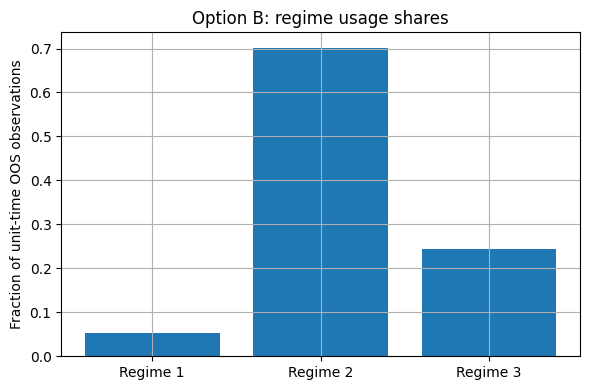

In [8]:
if artB is not None:
    dom_regime_B = np.argmax(gamma_B, axis=2)
    shares_B = np.bincount(dom_regime_B.reshape(-1), minlength=gamma_B.shape[2])
    shares_B = shares_B / shares_B.sum()

    share_df_B = pd.DataFrame({
        'regime': [f'Regime {k+1}' for k in range(gamma_B.shape[2])],
        'share': shares_B,
    })
    display(share_df_B)

    plt.figure(figsize=(6,4))
    plt.bar(share_df_B['regime'], share_df_B['share'])
    plt.title('Option B: regime usage shares')
    plt.ylabel('Fraction of unit-time OOS observations')
    plt.tight_layout()
    plt.savefig("fig_optionB_regime_shares_bar.png", dpi=300, bbox_inches="tight")
    plt.show()
    

### Option B average regime probability across units

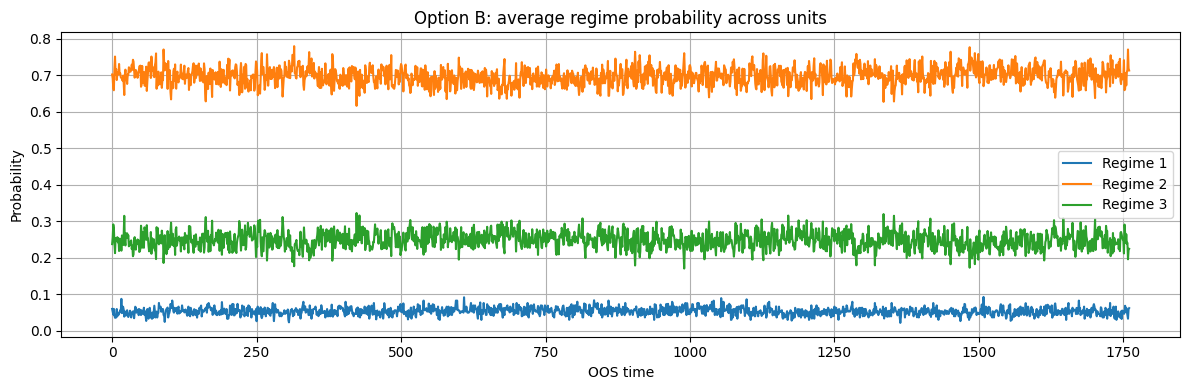

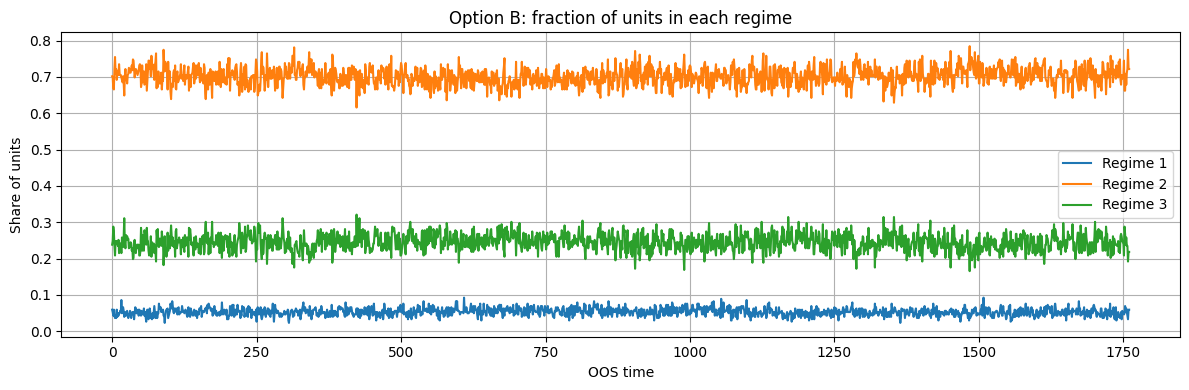

In [9]:
if artB is not None:
    mean_gamma_B = gamma_B.mean(axis=0)
    plt.figure(figsize=(12,4))
    for k in range(mean_gamma_B.shape[1]):
        plt.plot(mean_gamma_B[:,k], label=f'Regime {k+1}')
    plt.title('Option B: average regime probability across units')
    plt.xlabel('OOS time')
    plt.ylabel('Probability')
    plt.legend()
    plt.tight_layout()
    plt.savefig("fig_optionB_average_regime_probability_over_time.png", dpi=300, bbox_inches="tight")
    plt.show()

    frac_units = [(dom_regime_B == k).mean(axis=0) for k in range(gamma_B.shape[2])]
    plt.figure(figsize=(12,4))
    for k in range(len(frac_units)):
        plt.plot(frac_units[k], label=f'Regime {k+1}')
    plt.title('Option B: fraction of units in each regime')
    plt.xlabel('OOS time')
    plt.ylabel('Share of units')
    plt.legend()
    plt.tight_layout()
    plt.show()


### Option B transition matrix

,to_regime_1,to_regime_2,to_regime_3
from_regime_1,0.452596,0.398939,0.148465
from_regime_2,0.028414,0.816536,0.155050
from_regime_3,0.033681,0.505964,0.460355


Persistence (diagonal): [0.45259613 0.81653599 0.46035451]


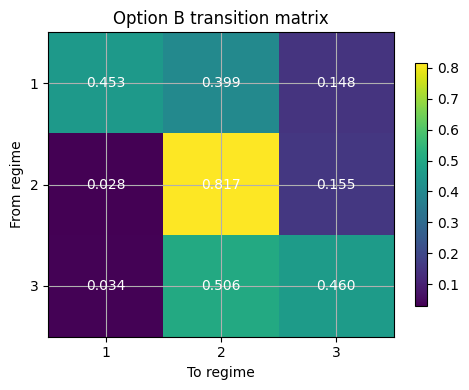

In [15]:
if artB is not None:
    display(pd.DataFrame(Pi_B, index=[f'from_regime_{k+1}' for k in range(Pi_B.shape[0])], columns=[f'to_regime_{k+1}' for k in range(Pi_B.shape[1])]))
    print('Persistence (diagonal):', np.diag(Pi_B))
    plot_transition_matrix(Pi_B, title='Option B transition matrix', file_name='fig_optionB_transition_matrix_heatmap.png')
    


### Option B regime heatmap by unit and time

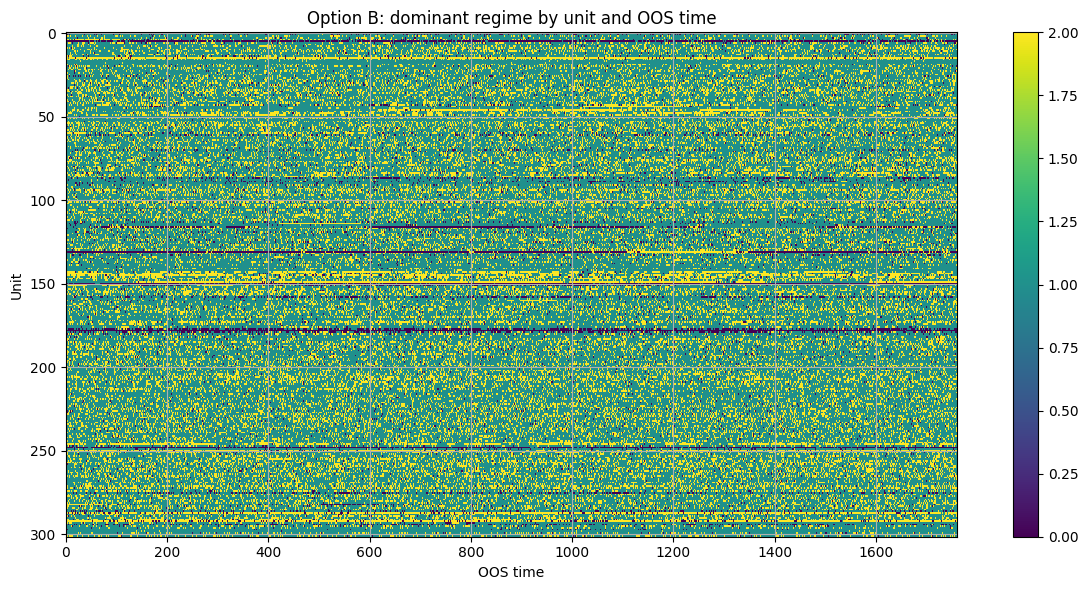

In [22]:
if artB is not None:
    plt.figure(figsize=(12,6))
    plt.imshow(dom_regime_B, aspect='auto', interpolation='nearest')
    plt.title('Option B: dominant regime by unit and OOS time')
    plt.xlabel('OOS time')
    plt.ylabel('Unit')
    plt.colorbar()
    plt.tight_layout()
    plt.savefig("fig_optionB_regime_by_unit_time_heatmap.png", dpi=300, bbox_inches="tight")
    plt.show()


### Option B AR summaries and heatmaps

,regime,mean_diag_A,mean_abs_offdiag_A
0,Regime 1,0.046452,0.013507
1,Regime 2,0.076172,0.009847
2,Regime 3,0.037179,0.012570


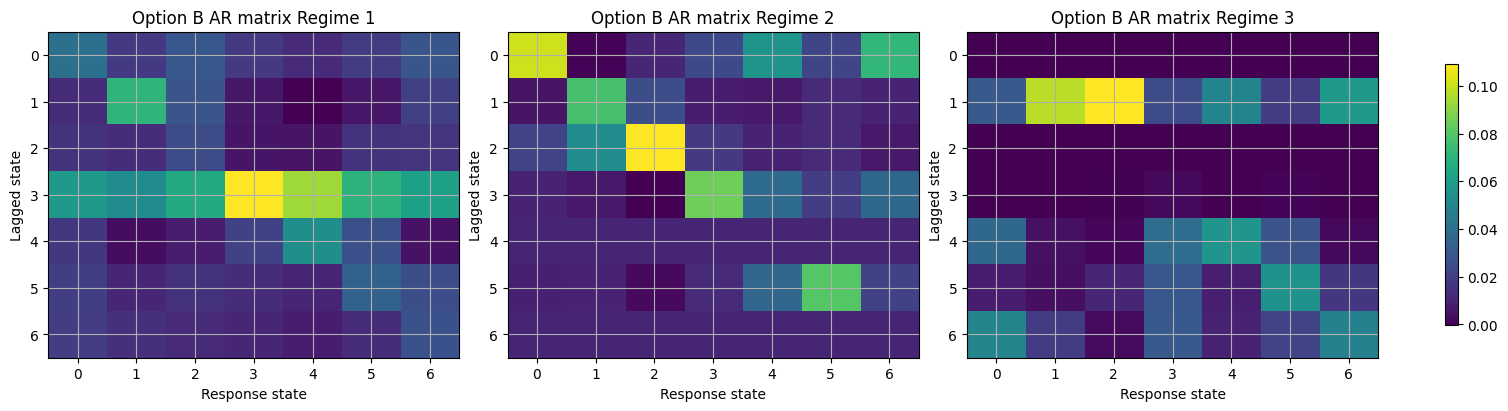

In [17]:
if artB is not None:
    A_summary_B = summarize_A(A_B)
    display(A_summary_B)
    plot_A_heatmaps(A_B, title_prefix='Option B AR matrix',file_name='fig_optionB_A_heatmaps_and_summary.png')


### Option B covariate importance

,regime,mean_abs_covariate_effect
0,Regime 1,0.109749
1,Regime 2,0.104957
2,Regime 3,0.095150


Regime 1


,covariate,importance
4,occupancy_roll_state_3,0.605392
5,occupancy_roll_state_4,0.541849
34,transition_roll_3_3,0.503159
42,transition_roll_4_4,0.426175
2,occupancy_roll_state_1,0.371456
6,occupancy_roll_state_5,0.324979
1,occupancy_roll_state_0,0.321026
7,occupancy_roll_state_6,0.292725
50,transition_roll_5_5,0.267279
10,transition_roll_0_0,0.264958


Regime 2


,covariate,importance
3,occupancy_roll_state_2,0.608237
4,occupancy_roll_state_3,0.601747
1,occupancy_roll_state_0,0.592744
34,transition_roll_3_3,0.494357
6,occupancy_roll_state_5,0.481521
26,transition_roll_2_2,0.476630
10,transition_roll_0_0,0.454958
50,transition_roll_5_5,0.381666
2,occupancy_roll_state_1,0.225487
18,transition_roll_1_1,0.152266


Regime 3


,covariate,importance
5,occupancy_roll_state_4,0.616169
2,occupancy_roll_state_1,0.535995
7,occupancy_roll_state_6,0.495655
42,transition_roll_4_4,0.485986
6,occupancy_roll_state_5,0.478315
50,transition_roll_5_5,0.365549
18,transition_roll_1_1,0.353689
58,transition_roll_6_6,0.335029
19,transition_roll_1_2,0.105550
52,transition_roll_6_0,0.100262


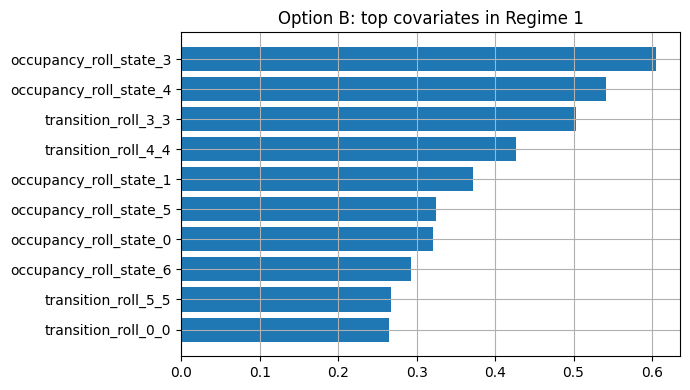

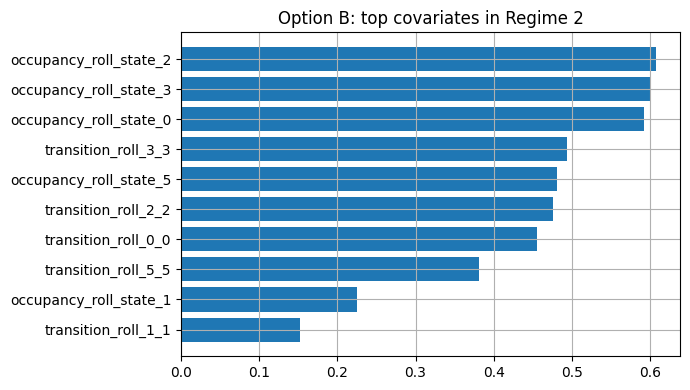

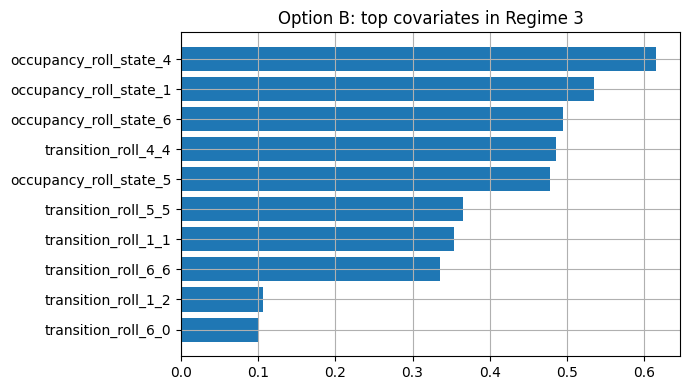

In [26]:
if artB is not None:
    B_summary_B = summarize_B(B_B)
    display(B_summary_B)

    topB = top_covariates(B_B, feature_names_B, top_n=15)
    for regime_name, df in topB.items():
        print(regime_name)
        display(df)

    for k in range(B_B.shape[0]):
        imp = np.mean(np.abs(B_B[k]), axis=1)
        df = pd.DataFrame({'covariate': feature_names_B, 'importance': imp}).sort_values('importance', ascending=False).head(10)
        plt.figure(figsize=(7,4))
        plt.barh(df['covariate'][::-1], df['importance'][::-1])
        plt.title(f'Option B: top covariates in Regime {k+1}')
        plt.tight_layout()
        plt.show()


### Option B confusion matrix and state recall

pred,0,1,2,3,4,5,6
true,,,,,,,
0,129533,223,5058,1947,12,787,0
1,2298,70894,2466,1090,211,187,282
2,7188,335,97193,1418,15,813,0
3,4235,182,1977,71589,34,519,0
4,2,1915,2,697,33152,45,79
5,2636,1375,1468,1363,71,53603,63
6,4,2187,0,341,71,25,32237


pred,0,1,2,3,4,5,6
true,,,,,,,
0,0.941647,0.001621,0.036769,0.014154,0.000087,0.005721,0.000000
1,0.029679,0.915612,0.031849,0.014078,0.002725,0.002415,0.003642
2,0.067201,0.003132,0.908668,0.013257,0.000140,0.007601,0.000000
3,0.053924,0.002317,0.025173,0.911544,0.000433,0.006608,0.000000
4,0.000056,0.053355,0.000056,0.019419,0.923660,0.001254,0.002201
5,0.043513,0.022698,0.024233,0.022500,0.001172,0.884845,0.001040
6,0.000115,0.062728,0.000000,0.009781,0.002036,0.000717,0.924624


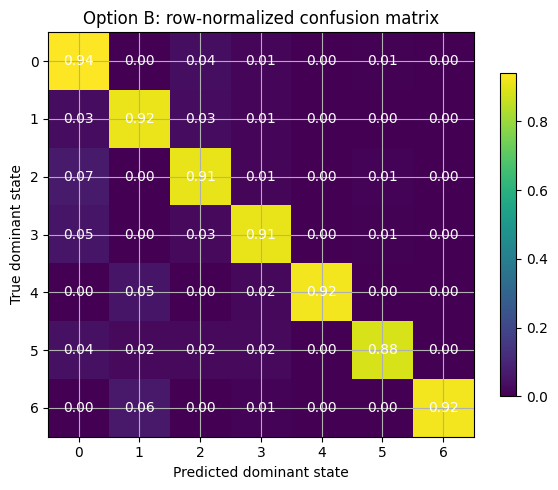

,state,recall
0,0,0.941647
1,1,0.915612
2,2,0.908668
3,3,0.911544
4,4,0.923660
5,5,0.884845
6,6,0.924624


In [30]:
if artB is not None:
    conf_B, conf_row_B = confusion_from_probs(y_true_B, y_pred_B)
    display(conf_B)
    display(conf_row_B)
    plot_confusion_heatmap(conf_row_B, title='Option B: row-normalized confusion matrix',file_name='fig_optionB_confusion_matrix_and_recall.png')

    state_recall_B = np.diag(conf_B.values) / conf_B.sum(axis=1).values
    recall_df_B = pd.DataFrame({'state': conf_B.index, 'recall': state_recall_B})
    display(recall_df_B)


### Option B switching heterogeneity across units

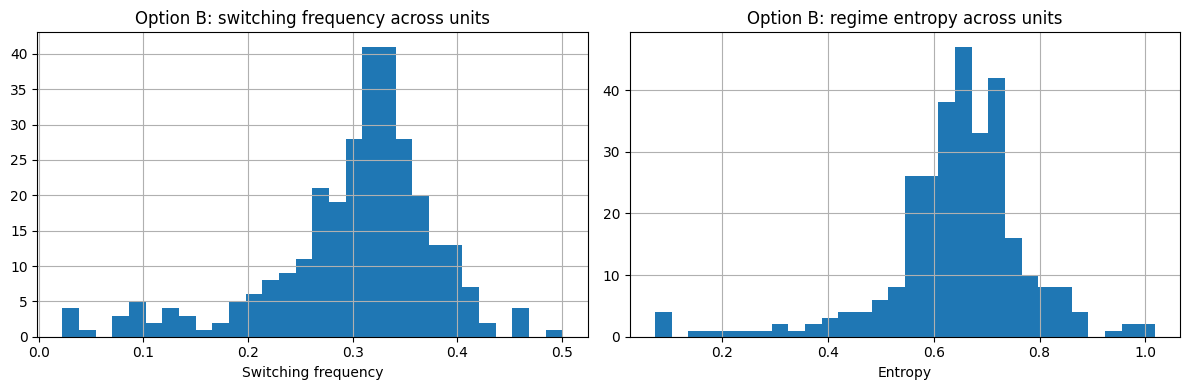

Most stable units: [ 18 298 178  17 300 149 297 142 140  44]
Most dynamic units: [276  43 179  77 117 272 265 274 271 129]


In [21]:
if artB is not None:
    z_B = dom_regime_B
    N_B, T_B = z_B.shape
    switch_rate_B = []
    regime_entropy_B = []

    for i in range(N_B):
        switches = np.sum(z_B[i,1:] != z_B[i,:-1])
        switch_rate_B.append(switches / max(T_B - 1, 1))
        p_i = gamma_B[i].mean(axis=0)
        p_i = np.clip(p_i, 1e-12, None)
        p_i = p_i / p_i.sum()
        regime_entropy_B.append(-np.sum(p_i * np.log(p_i)))

    switch_rate_B = np.array(switch_rate_B)
    regime_entropy_B = np.array(regime_entropy_B)

    fig, axes = plt.subplots(1, 2, figsize=(12,4))
    axes[0].hist(switch_rate_B, bins=30)
    axes[0].set_title('Option B: switching frequency across units')
    axes[0].set_xlabel('Switching frequency')
    axes[1].hist(regime_entropy_B, bins=30)
    axes[1].set_title('Option B: regime entropy across units')
    axes[1].set_xlabel('Entropy')
    plt.tight_layout()
    plt.savefig("fig_optionB_switching_heterogeneity.png", dpi=300, bbox_inches="tight")
    plt.show()

    stable_units = np.argsort(switch_rate_B)[:10]
    dynamic_units = np.argsort(switch_rate_B)[-10:]
    print('Most stable units:', stable_units)
    print('Most dynamic units:', dynamic_units)


### Option B regime-specific state interaction networks

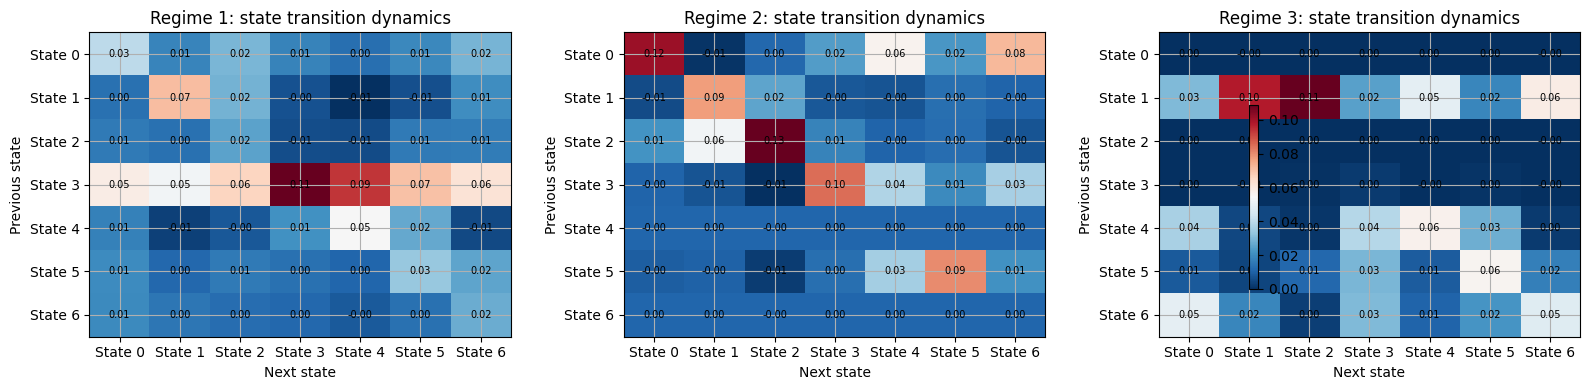

In [32]:
# ----------------------------------------------------
# Regime-specific brain-state transition heatmaps
# ----------------------------------------------------

state_names = [f"State {i}" for i in range(A_B.shape[1])]

fig, axes = plt.subplots(1, A_B.shape[0], figsize=(16,4))

for k in range(A_B.shape[0]):

    ax = axes[k]

    im = ax.imshow(A_B[k], cmap="RdBu_r", aspect="auto")

    ax.set_title(f"Regime {k+1}: state transition dynamics")

    ax.set_xticks(range(len(state_names)))
    ax.set_yticks(range(len(state_names)))

    ax.set_xticklabels(state_names)
    ax.set_yticklabels(state_names)

    ax.set_xlabel("Next state")
    ax.set_ylabel("Previous state")

    for i in range(A_B.shape[1]):
        for j in range(A_B.shape[2]):
            ax.text(j, i, f"{A_B[k,i,j]:.2f}",
                    ha="center", va="center",
                    fontsize=7)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)

plt.tight_layout()
plt.show()

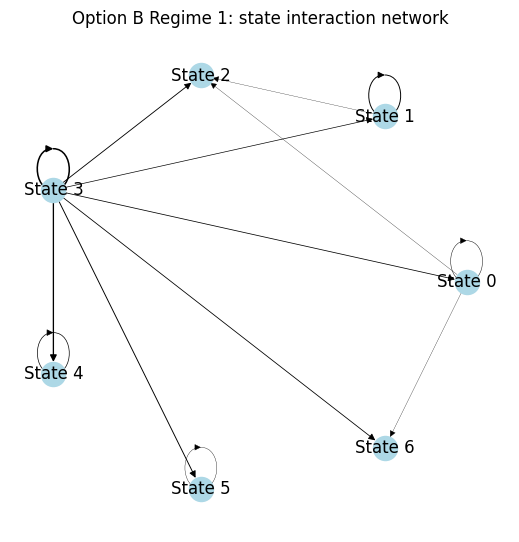

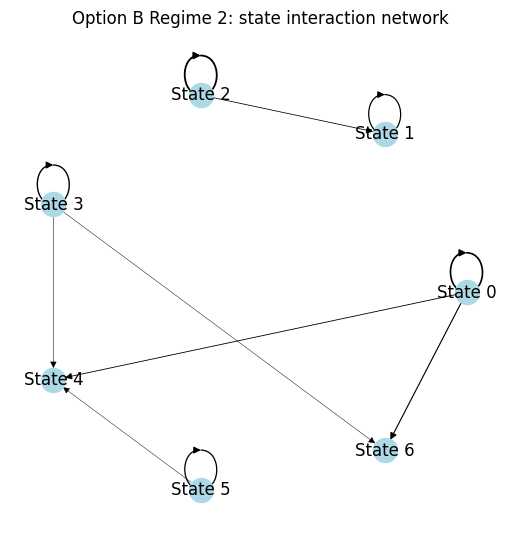

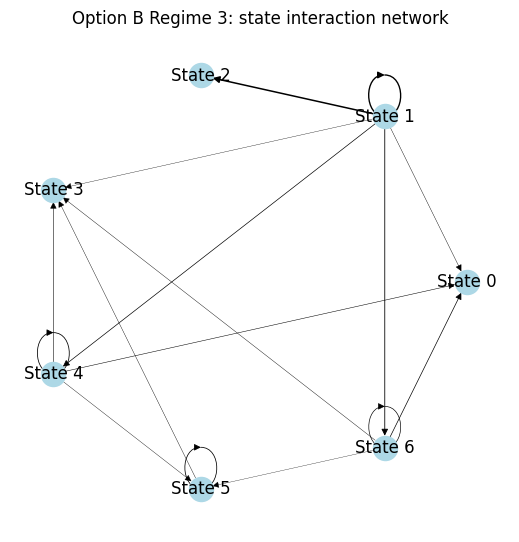

In [33]:
if artB is not None:
    for k in range(A_B.shape[0]):
        plot_state_interaction_network(A_B[k], threshold=0.02, title=f'Option B Regime {k+1}: state interaction network')


In [34]:
# ---------------------------------------------------------
# Regime × Task alignment
# ---------------------------------------------------------

tasks = artB["tasks"]          # length N
gamma = gamma_B                # shape (N, T, K)

N, T, K = gamma.shape

# one task per unit, repeated across OOS time
tasks_rep = np.repeat(tasks, T)

# dominant regime for each unit-time observation
dom_regime = np.argmax(gamma, axis=2).reshape(-1)

print("len(tasks_rep):", len(tasks_rep))
print("len(dom_regime):", len(dom_regime))

df = pd.DataFrame({
    "task": tasks_rep,
    "regime": dom_regime
})

regime_task = (
    df.groupby(["task", "regime"])
      .size()
      .unstack(fill_value=0)
)

regime_task = regime_task.div(regime_task.sum(axis=1), axis=0)

display(regime_task)

len(tasks_rep): 531822
len(dom_regime): 531822


regime,0,1,2
task,,,
DespicableMe,0.034369,0.733953,0.231677
DiaryOfAWimpyKid,0.084149,0.682076,0.233775
FunwithFractals,0.081589,0.695127,0.223284
RestingState,0.038854,0.688396,0.272750
ThePresent,0.029452,0.708958,0.261591


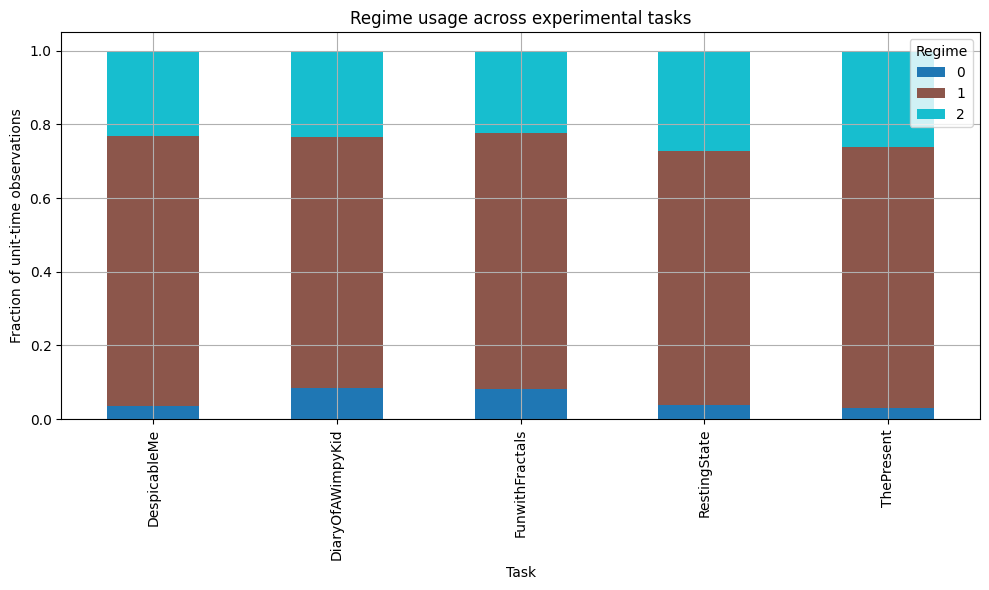

In [35]:
ax = regime_task.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab10"
)

ax.set_title("Regime usage across experimental tasks")
ax.set_ylabel("Fraction of unit-time observations")
ax.set_xlabel("Task")
ax.legend(title="Regime")
plt.tight_layout()
plt.savefig("fig_regime_task_alignment_hard.png", dpi=300, bbox_inches="tight")
plt.show()

In [37]:
tasks = artB["tasks"]
gamma = gamma_B

N, T, K = gamma.shape
task_names = pd.Index(tasks).unique()

rows = []
for task in task_names:
    idx_units = np.where(tasks == task)[0]
    if len(idx_units) == 0:
        continue
    mean_probs = gamma[idx_units].mean(axis=(0, 1))
    row = {"task": task}
    for k in range(K):
        row[f"Regime {k+1}"] = mean_probs[k]
    rows.append(row)

regime_task_soft = pd.DataFrame(rows).set_index("task")
display(regime_task_soft)

,Regime 1,Regime 2,Regime 3
task,,,
ThePresent,0.029563,0.706804,0.263633
FunwithFractals,0.081625,0.689276,0.229099
DiaryOfAWimpyKid,0.084143,0.680183,0.235674
DespicableMe,0.034364,0.726016,0.239620
RestingState,0.038858,0.686903,0.274239


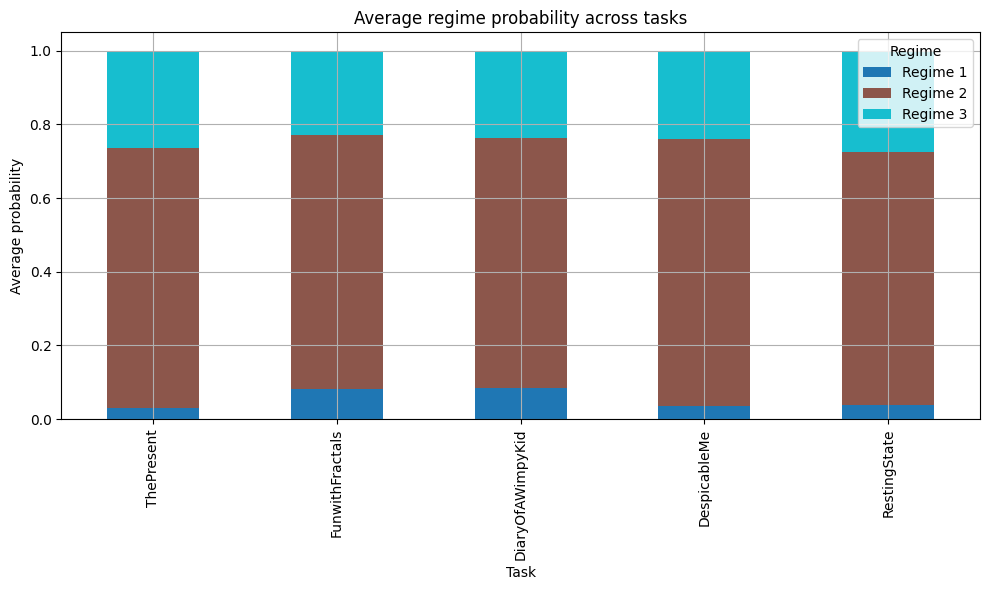

In [38]:
ax = regime_task_soft.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6),
    colormap="tab10"
)

ax.set_title("Average regime probability across tasks")
ax.set_ylabel("Average probability")
ax.set_xlabel("Task")
ax.legend(title="Regime")
plt.tight_layout()
plt.savefig("fig_regime_task_alignment_soft.png", dpi=300, bbox_inches="tight")
plt.show()

## Option A diagnostics

,to_regime_1,to_regime_2,to_regime_3
from_regime_1,0.501339,0.324290,0.174371
from_regime_2,0.141360,0.591457,0.267183
from_regime_3,0.178181,0.303528,0.518291


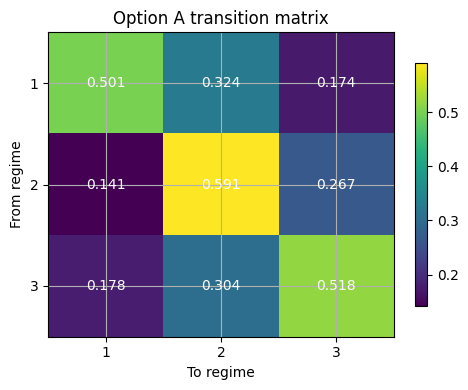

,regime,mean_diag_A,mean_abs_offdiag_A
0,Regime 1,0.093494,0.008766
1,Regime 2,0.093336,0.008913
2,Regime 3,0.092122,0.008999


,regime,mean_abs_covariate_effect
0,Regime 1,0.171354
1,Regime 2,0.170997
2,Regime 3,0.171355


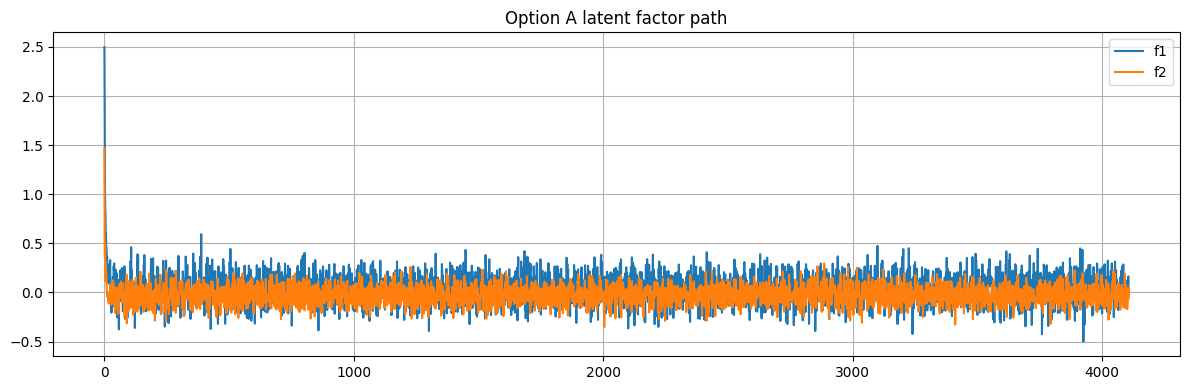

In [30]:
artA = loaded.get('optA_artifacts')
if artA is None:
    print('Option A artifacts not found.')
else:
    A_A = artA['A']
    B_A = artA['B']
    Pi_A = artA['Pi']
    f_t_A = artA['f_t']
    display(pd.DataFrame(Pi_A, index=[f'from_regime_{k+1}' for k in range(Pi_A.shape[0])], columns=[f'to_regime_{k+1}' for k in range(Pi_A.shape[1])]))
    plot_transition_matrix(Pi_A, title='Option A transition matrix')
    display(summarize_A(A_A))
    display(summarize_B(B_A))
    plt.figure(figsize=(12,4))
    if f_t_A.ndim == 2:
        for j in range(f_t_A.shape[1]):
            plt.plot(f_t_A[:,j], label=f'f{j+1}')
        plt.legend()
    plt.title('Option A latent factor path')
    plt.tight_layout()
    plt.show()


## Option C diagnostics

,to_regime_1,to_regime_2,to_regime_3
from_regime_1,0.479660,0.270915,0.249425
from_regime_2,0.183366,0.561817,0.254818
from_regime_3,0.175372,0.262702,0.561926


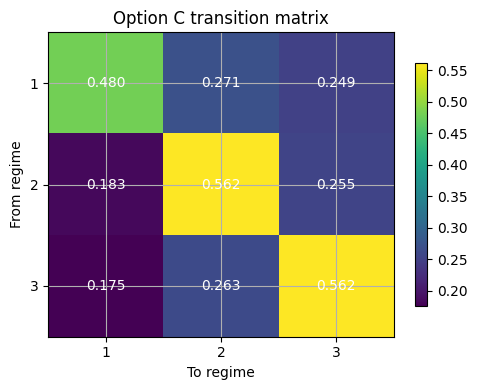

In [31]:
artC = loaded.get('optC_artifacts')
if artC is None:
    print('Option C artifacts not found.')
else:
    Pi_C = artC['Pi']
    display(pd.DataFrame(Pi_C, index=[f'from_regime_{k+1}' for k in range(Pi_C.shape[0])], columns=[f'to_regime_{k+1}' for k in range(Pi_C.shape[1])]))
    plot_transition_matrix(Pi_C, title='Option C transition matrix')


## Global switching prototype diagnostics

,to_regime_1,to_regime_2,to_regime_3
from_regime_1,0.614244,0.171255,0.214501
from_regime_2,0.302990,0.454837,0.242173
from_regime_3,0.274010,0.176489,0.549501


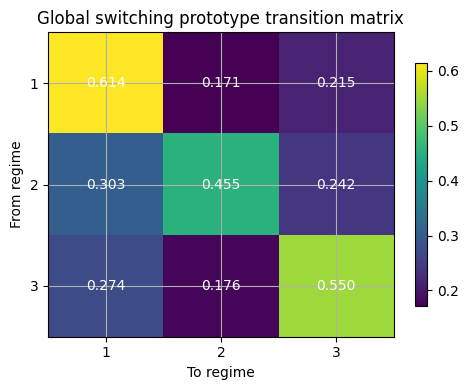

In [32]:
artS = loaded.get('switch_artifacts')
if artS is None:
    print('Switching prototype artifacts not found.')
else:
    Pi_S = artS['Pi']
    display(pd.DataFrame(Pi_S, index=[f'from_regime_{k+1}' for k in range(Pi_S.shape[0])], columns=[f'to_regime_{k+1}' for k in range(Pi_S.shape[1])]))
    plot_transition_matrix(Pi_S, title='Global switching prototype transition matrix')


## Final takeaway slide

In [33]:
takeaway = pd.DataFrame([
    {'Finding': 'Best-performing model', 'Conclusion': 'Option B: Unit-specific switching PVAR'},
    {'Finding': 'Main structural insight', 'Conclusion': 'Regime timing is heterogeneous across units'},
    {'Finding': 'Global vs unit-specific', 'Conclusion': 'Unit-specific switching outperforms global switching'},
    {'Finding': 'Latent compression', 'Conclusion': 'SLDS-style latent compression does not outperform direct switching in the 7-state space'},
])
display(takeaway)


,Finding,Conclusion
0,Best-performing model,Option B: Unit-specific switching PVAR
1,Main structural insight,Regime timing is heterogeneous across units
2,Global vs unit-specific,Unit-specific switching outperforms global swi...
3,Latent compression,SLDS-style latent compression does not outperf...
